# Platform Stabilogram

This file contains:
- extration of stabilogrma from force platform gait-line.csv
- stabilogram is synchronizatinized with begin time extracted from .xml
- stabilogram is centered
- CoP variables are extracted

At the end of the file, there is a comparison plot with radar stabilogram

In [327]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from code_descriptors_postural_control.stabilogram.stato import Stabilogram
from code_descriptors_postural_control.descriptors import compute_all_features

## Here

In [ ]:
xml_file = "../data/dataset1/platform/data5.xml"
csv_gait_file = "../data/dataset1/platform/data5_gait.csv"

In [ ]:

def get_begin_time(xml_filepath_filenam):
    tree = ET.parse(xml_filepath_filenam)
    root = tree.getroot()

    # définir le namespace
    ns = {"z": "http://www.zebris.de/measurements"}

    # trouver la valeur de begin
    begin = root.find(".//z:clip/z:begin", ns)

    if begin is not None:
        return float(begin.text)
    return 0

print(get_begin_time(xml_file))

In [ ]:
def get_gait_samples(csv_file):

    df = pd.read_csv(csv_file, skiprows=3)

    times = df["time"].to_numpy()
    xs = df["x"].to_numpy()
    ys = df["y"].to_numpy()

    return times, xs, ys


In [ ]:
begin_time = get_begin_time(xml_file)
times, x_pos, y_pos = get_gait_samples(csv_gait_file)


In [ ]:
times = times + begin_time

positive_time = np.where((times >= 0) & (times <= 10))
times = times[positive_time]
x_pos = x_pos[positive_time]
y_pos = y_pos[positive_time]

In [ ]:

# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Temps (s)")
plt.ylabel("x (mm)")
plt.title("x en fonction du temps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Temps (s)")
plt.ylabel("y (mm)")
plt.title("y en fonction du temps")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


## Centered

In [ ]:
x_pos -= np.mean(x_pos)
y_pos -= np.mean(y_pos)

# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("ML (mm)")
plt.title("Centered ML")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("AP (mm)")
plt.title("Centered ML")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("ML (mm)")
plt.ylabel("AP (mm)")
plt.title("Force plateform Statokinesigram Centered", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


## Normalization

In [ ]:
x = x_pos - np.mean(x_pos)
y = y_pos - np.mean(y_pos)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

plt.figure()
sc = plt.scatter(x_norm, y_norm, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Force plateform statokinesigram", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

## Getting CoP variables

In [ ]:
data = np.array([x_pos/10, y_pos/10]).T
stato = Stabilogram()
stato.from_array(array=data, original_frequency=60)

plt.plot(stato.medio_lateral)
plt.plot(stato.antero_posterior)

In [ ]:
sway_density_radius = 0.3 # 3 mm
params_dic = {"sway_density_radius": sway_density_radius}
features = compute_all_features(stato, params_dic=params_dic)

In [ ]:
features

In [329]:

def get_descriptors(x_pos, y_pos, time):
    data = np.array([x_pos/10, y_pos/10]).T

    stato = Stabilogram()
    stato.from_array(array=data, original_frequency=1/time[1])
    sway_density_radius = 0.3 # 3 mm
    params_dic = {"sway_density_radius": sway_density_radius}
    features = compute_all_features(stato, params_dic=params_dic)

    return features 

## Little comparison of radar based stabilogram and force platform one 


In [ ]:
# df = pd.read_csv("../results/antoine/test1_position.csv")
# time_radar = df["time"].values
# x_pos_radar = df["x_pos"].values
# y_pos_radar = df["y_pos"].values

# plt.figure(figsize=(10, 6))
# plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

# plt.subplot(2, 1, 1)
# plt.plot(time_radar, x_pos_radar, label="radar")
# plt.plot(times, x_pos, label="force platform")
# plt.xlabel("time (s)")
# plt.ylabel("ML (mm)")
# plt.title("ML axis")
# plt.legend()
# plt.grid

# plt.subplot(2, 1, 2)
# plt.plot(time_radar, y_pos_radar, label="radar")
# plt.plot(times, y_pos, label="force platform")
# plt.xlabel("time (s)")
# plt.ylabel("AP (mm)")
# plt.title("AP axis")
# plt.legend()
# plt.grid

# plt.tight_layout(pad=2)
# plt.show()

In [ ]:
df = pd.read_csv("../results/tables/dataset1/position/data5_radarposition.csv")
time_radar = df["time"].values
x_pos_radar = df["x_pos"].values
y_pos_radar = df["y_pos"].values

plt.figure()
plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

plt.subplot(2, 1, 1)

ax1 = plt.gca()  # axe gauche
ax1.plot(time_radar, x_pos_radar, label="radar", color='blue')
ax1.set_ylabel("Radar (mm)", color='blue')

ax2 = ax1.twinx()  # axe droit
ax2.plot(times, x_pos, label="force platform", color='red')
ax2.set_ylabel("Force platform (mm)", color='red')

plt.xlabel("time (s)")
plt.title("ML axis")
plt.grid()

plt.subplot(2, 1, 2)
ax1 = plt.gca()  # axe gauche
ax1.plot(time_radar, y_pos_radar, label="radar", color='blue')
ax1.set_ylabel("Radar (mm)", color='blue')

ax2 = ax1.twinx()  # axe droit
ax2.plot(times, y_pos, label="force platform", color='red')
ax2.set_ylabel("Force platform (mm)", color='red')

plt.xlabel("time (s)")
plt.title("AP axis")
plt.grid()

plt.tight_layout(pad=2)
plt.show()

In [ ]:
def plot_stabilo_comparison(radar_stabilo_file, pf_time, pf_x, pf_y, save_path=None):

    df = pd.read_csv(radar_stabilo_file)
    time_radar = df["time"].values
    x_pos_radar = df["x_pos"].values
    y_pos_radar = df["y_pos"].values

    plt.figure(figsize=(10, 6))
    plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

    ratio_x =  abs(np.log10(np.max(np.abs(x_pos_radar))) - np.log10(np.max(np.abs(pf_x)))) if (np.max(np.abs(x_pos_radar)) != 0 and np.max(np.abs(pf_x)) != 0) else 0
    ratio_y =  abs(np.log10(np.max(np.abs(y_pos_radar))) - np.log10(np.max(np.abs(pf_y)))) if (np.max(np.abs(y_pos_radar)) != 0 and np.max(np.abs(pf_y)) != 0) else 0

    print(ratio_x)
    print(ratio_y)


    # SI L'ORDRE DE GRANDEUR ENTRE RADAR ET PLATEFORME N'ETS PAS CORRECT
    if abs(ratio_x) > 0.5: 
    
        plt.subplot(2, 1, 1)

        ax1 = plt.gca()  # axe gauche
        ax1.plot(time_radar, x_pos_radar, label="radar", color='navy')
        ax1.set_ylabel("Radar (mm)", color='navy')

        ax2 = ax1.twinx()  # axe droit
        ax2.plot(pf_time, pf_x, label="force platform", color='orange')
        ax2.set_ylabel("Force platform (mm)", color='orange')

        plt.xlabel("time (s)")
        plt.title("ML axis")
        plt.grid()

    else : 
        plt.subplot(2, 1, 1)
        plt.plot(time_radar, x_pos_radar, label="radar")
        plt.plot(times, x_pos, label="force platform")
        plt.xlabel("time (s)")
        plt.ylabel("ML (mm)")
        plt.title("ML axis")
        plt.legend()
        plt.grid

    if abs(ratio_y) > 0.5:
        plt.subplot(2, 1, 2)
        ax1 = plt.gca()  # axe gauche
        ax1.plot(time_radar, y_pos_radar, label="radar", color='navy')
        ax1.set_ylabel("Radar (mm)", color='navy')

        ax2 = ax1.twinx()  # axe droit
        ax2.plot(pf_time, pf_y, label="force platform", color='orange')
        ax2.set_ylabel("Force platform (mm)", color='orange')

        plt.xlabel("time (s)")
        plt.title("AP axis")
        plt.grid()

    else : 
        plt.subplot(2, 1, 2)
        plt.plot(time_radar, y_pos_radar, label="radar")
        plt.plot(times, y_pos, label="force platform")
        plt.xlabel("time (s)")
        plt.ylabel("AP (mm)")
        plt.title("AP axis")
        plt.legend()
        plt.grid

        
    plt.tight_layout(pad=2)

    if save_path is not None:
        plt.savefig(save_path)
    plt.show()


## Dataset1 platform stabilogram and comparison

processing test file 1 !!!!
0.07801295257882646
0.10368769475099548


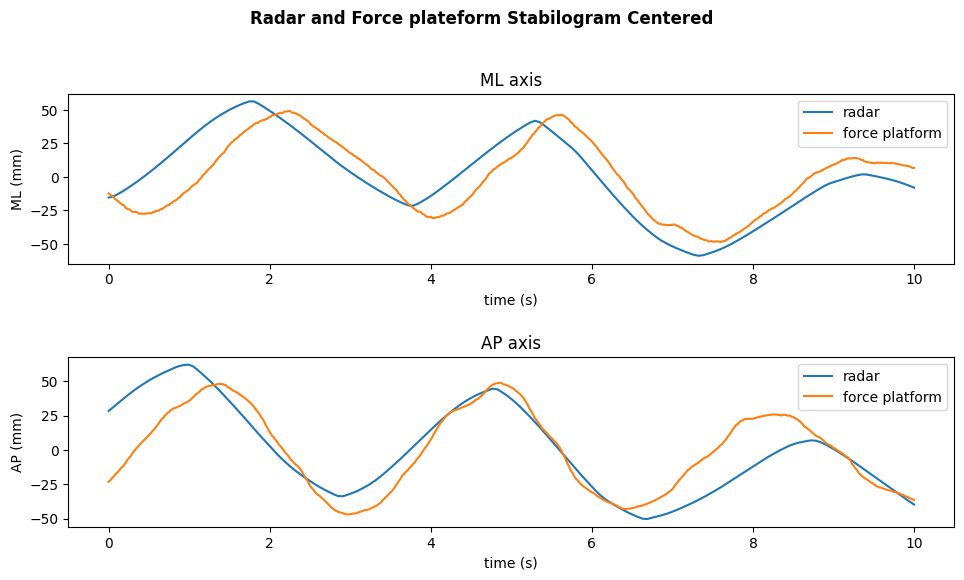

processing test file 2 !!!!
0.007366971441860937
0.08591272474324496


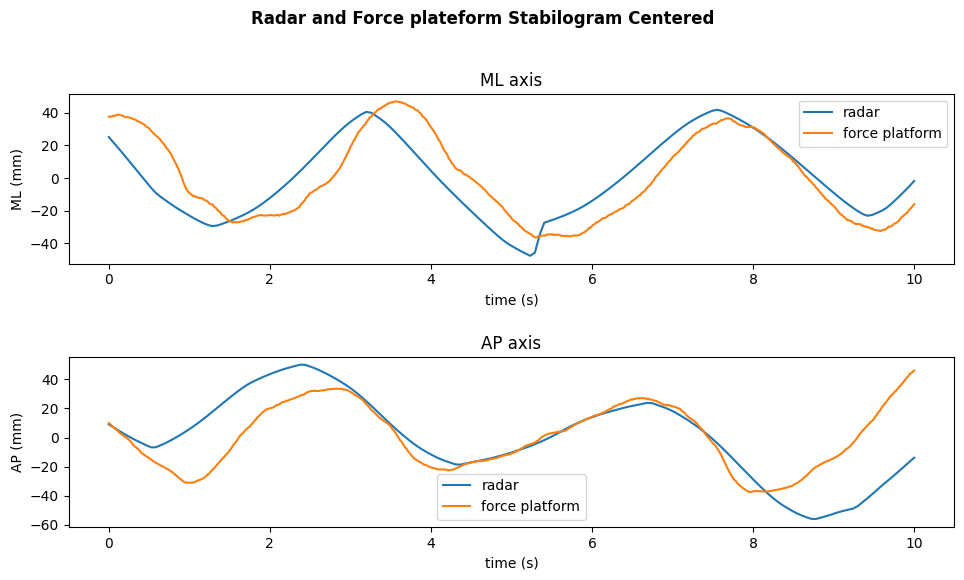

processing test file 3 !!!!
0.06772075325699278
0.01998426936119624


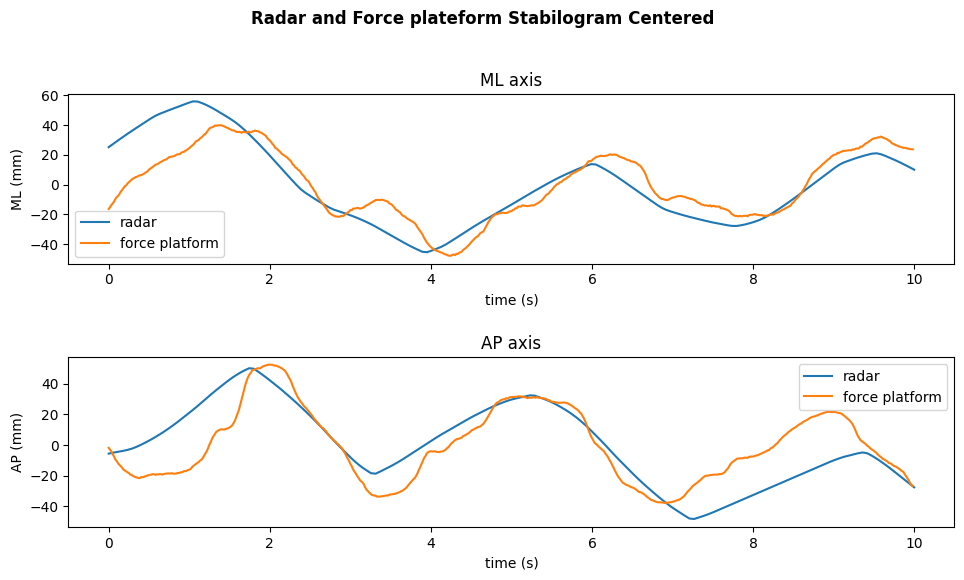

processing test file 4 !!!!
0.06097698015532127
0.005868587360862598


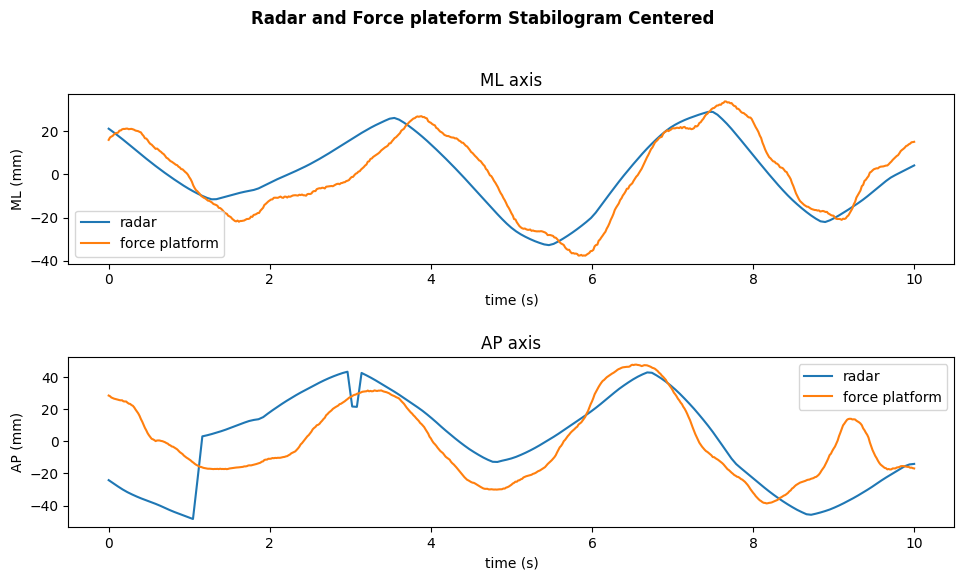

processing test file 5 !!!!
2.043392690146702
0.6092606524286258


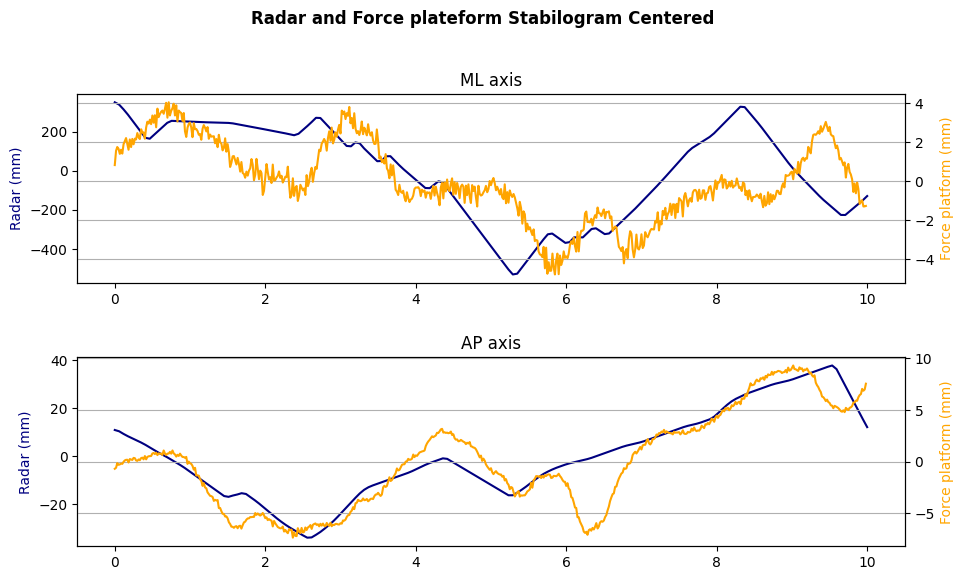

In [375]:
features_list = []

for i in range(1, 6):
    print(f"processing test file {i} !!!!")

    xml_file = f"../data/dataset1/platform/data{i}.xml"
    gait_file = f"../data/dataset1/platform/data{i}_gait.csv"
    radar_stabilo_file = f"../results/tables/dataset1/position/data{i}_radarposition.csv"

    begin_time = get_begin_time(xml_file)
    times, x_pos, y_pos = get_gait_samples(gait_file)

    times = times + begin_time
    positive_time = np.where((times >= 0) & (times <= 10))
    times = times[positive_time]
    x_pos = x_pos[positive_time]
    y_pos = y_pos[positive_time]

    x_pos -= np.mean(x_pos)
    y_pos -= np.mean(y_pos)

    plot_stabilo_comparison(radar_stabilo_file, times, x_pos, y_pos, f"../results/figures/dataset1/data{i}_stabilo.png")

    features = get_descriptors(x_pos, y_pos, times)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/tables/dataset1/platform_descriptors.csv")

## Dataset2 platform stabilogram and comparison

processing test file 1 !!!!
1.3866917548254467
2.0604888730282083


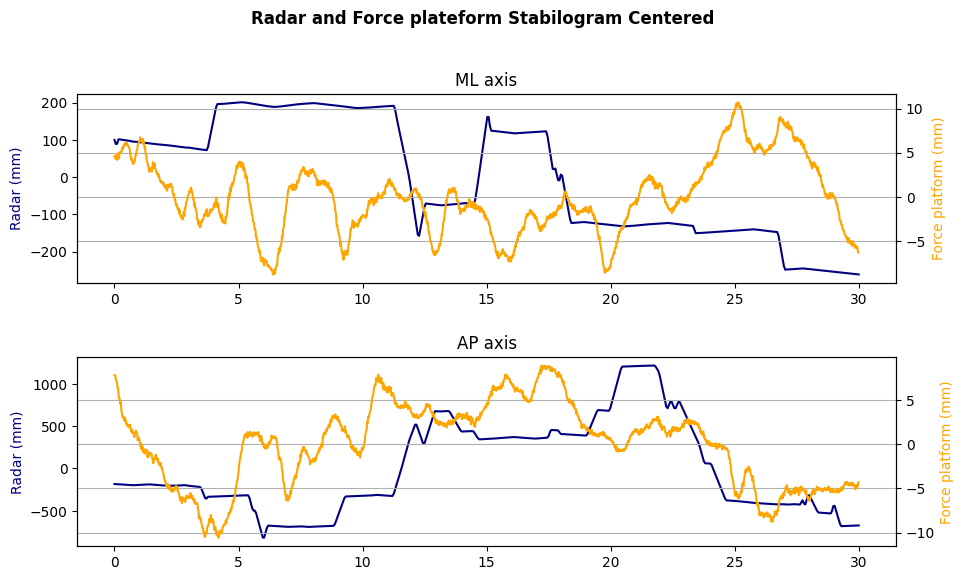

processing test file 2 !!!!
1.5154435199476812
1.8050328370745938


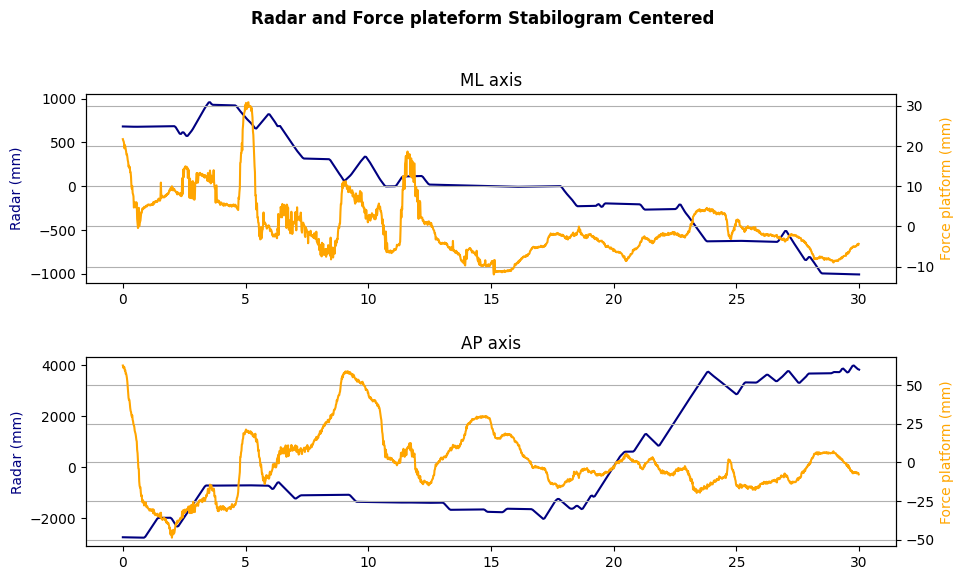

processing test file 3 !!!!
1.4338017716608982
0.5862201347277429


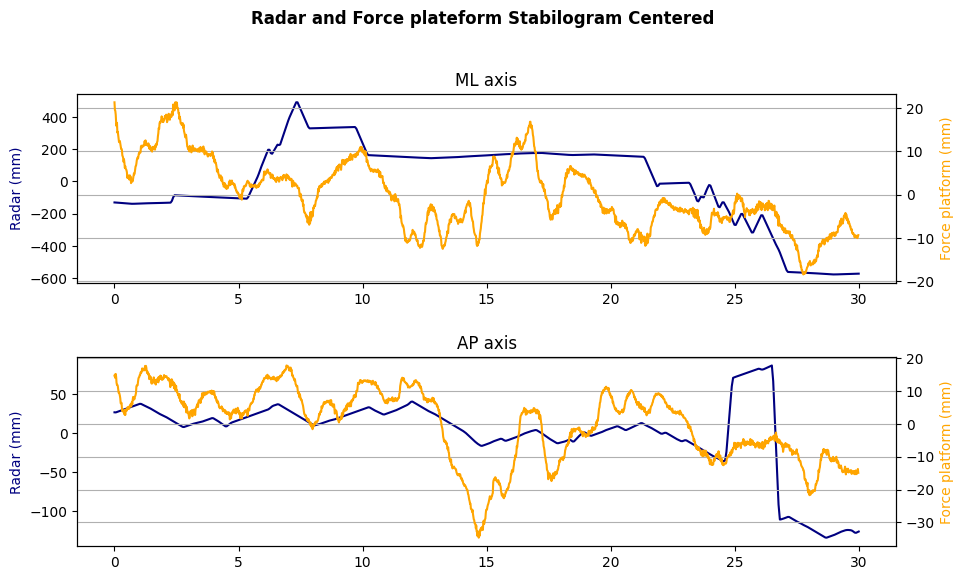

processing test file 4 !!!!
1.478865960239942
1.6549587229558749


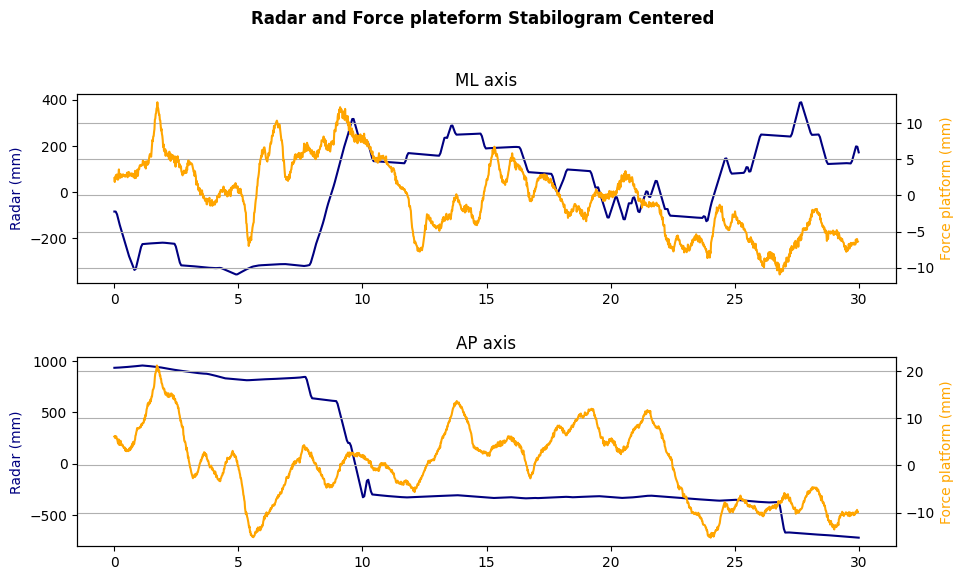

processing test file 5 !!!!
1.5895526173883174
2.4138837818940253


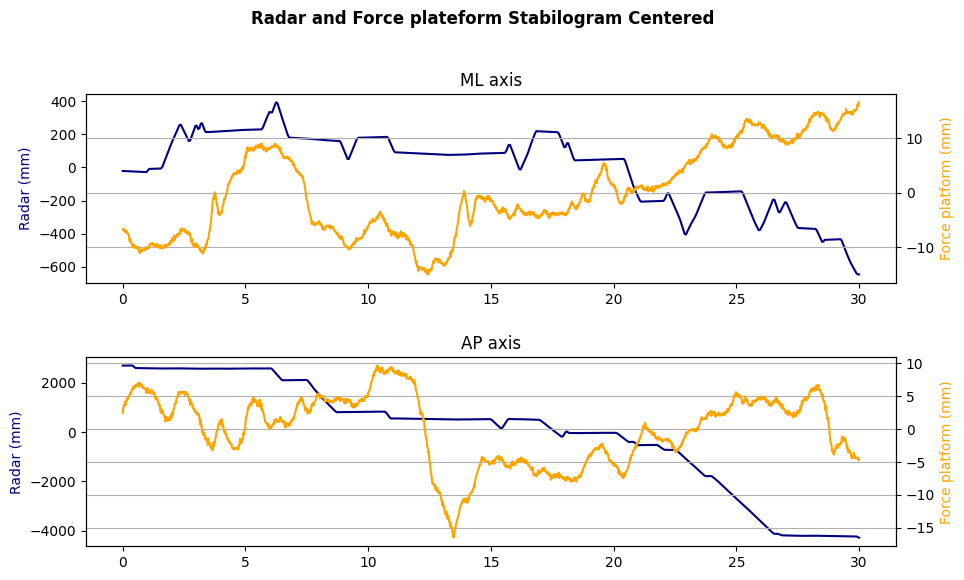

processing test file 6 !!!!
2.001276157699902
2.6269561038732756


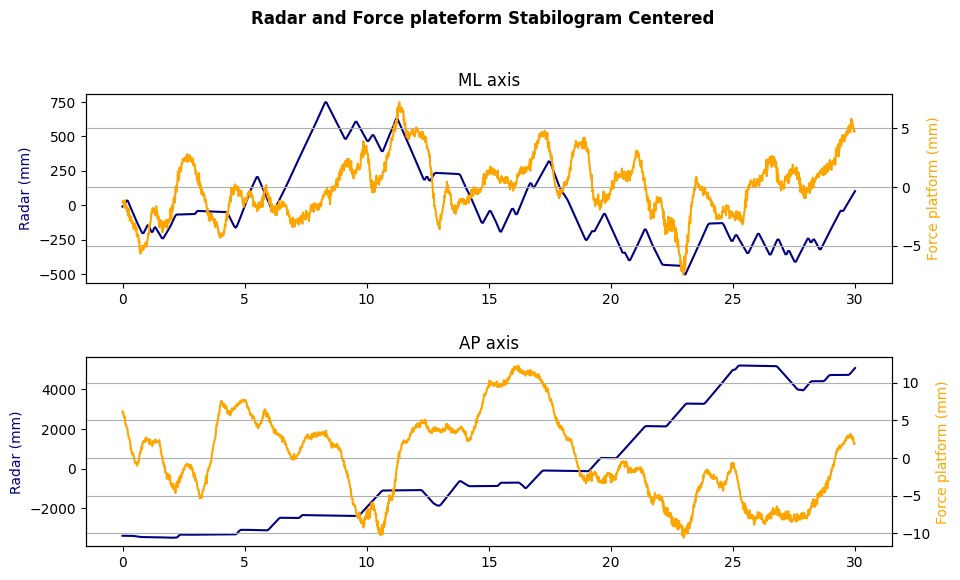

processing test file 7 !!!!
1.5407250386951061
2.7808330874746066


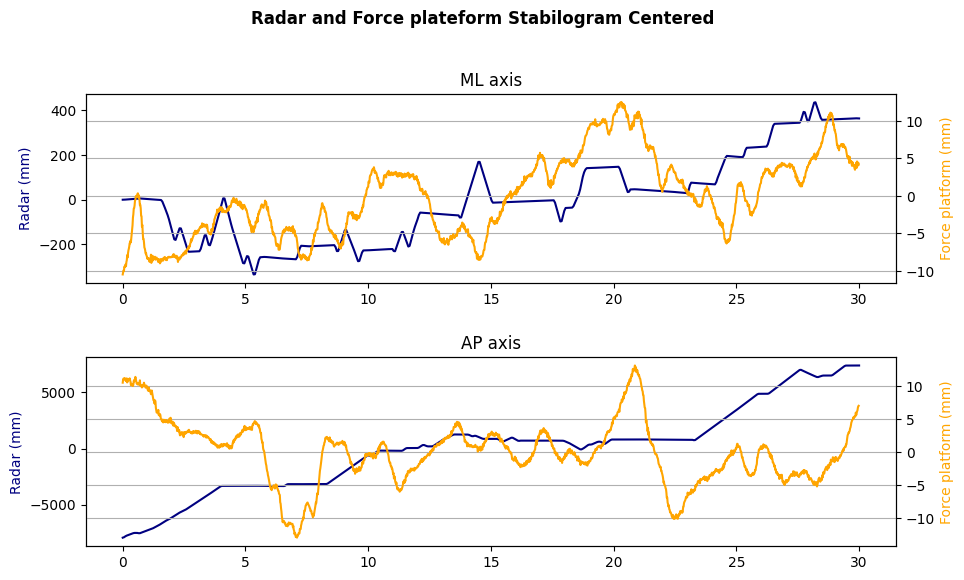

processing test file 8 !!!!
0.20126356052312788
0.4482101217492378


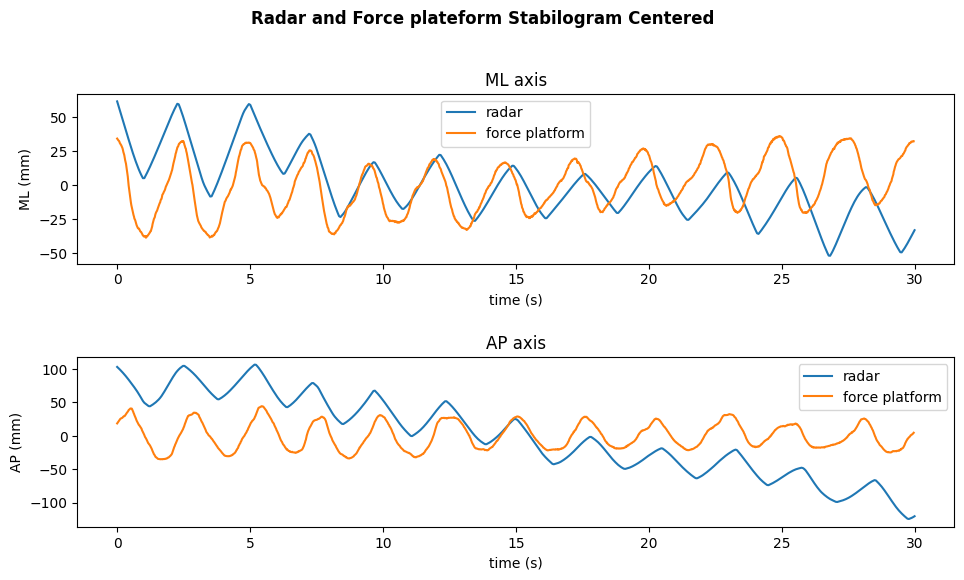

processing test file 9 !!!!
0.06840017798137543
0.36257740853152587


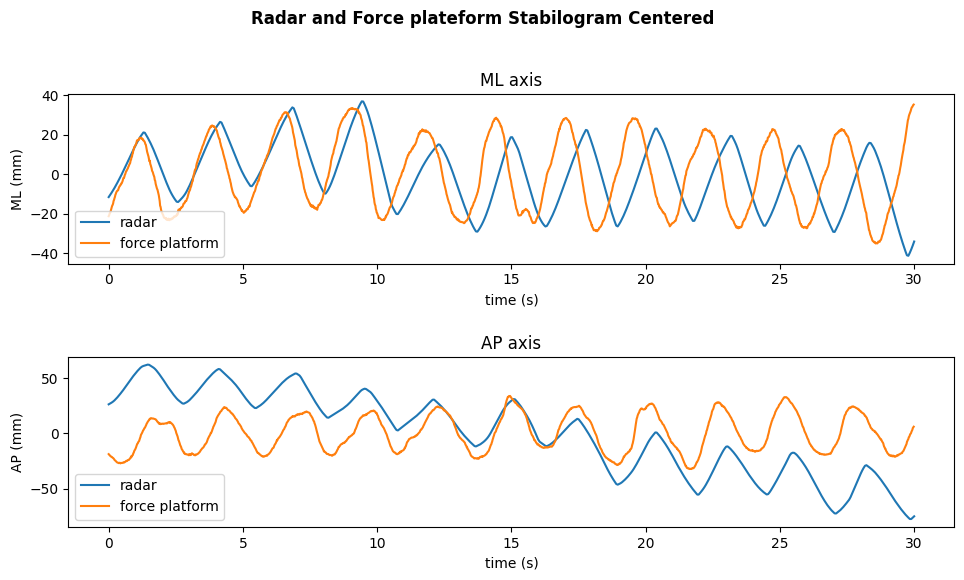

processing test file 10 !!!!
0.17259049167040952
0.028594823928590696


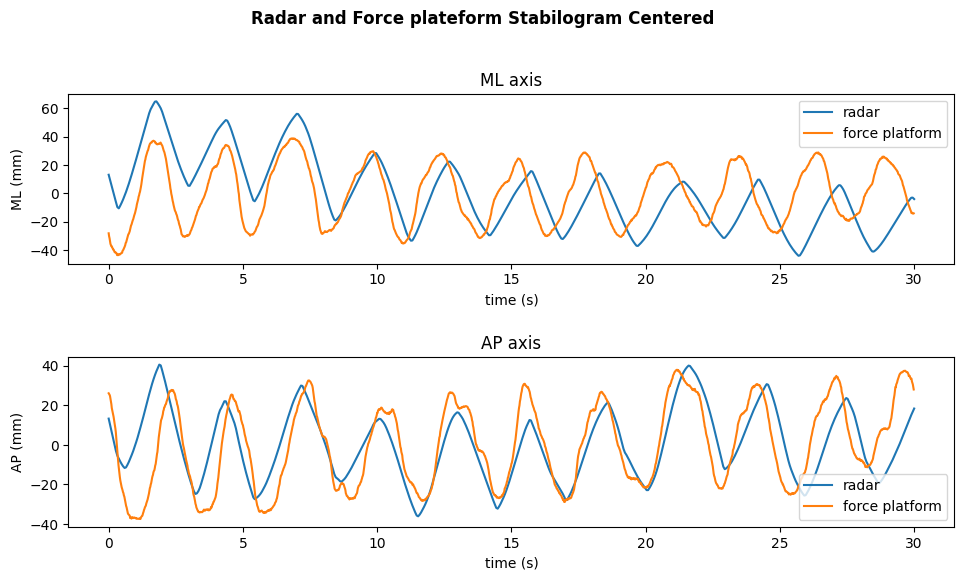

processing test file 11 !!!!
0.24503589086061162
0.25910685834156566


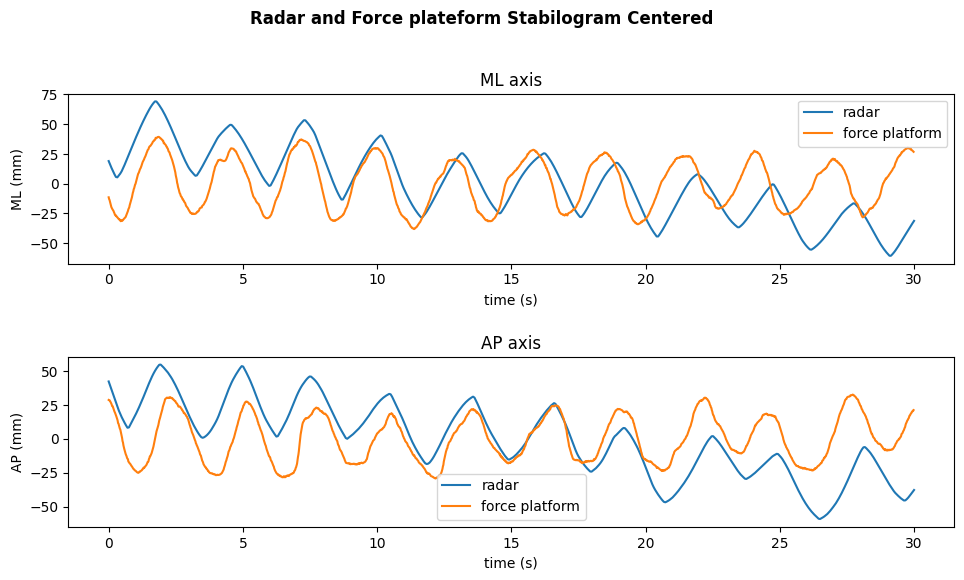

processing test file 12 !!!!
0.20459289459025976
0.1899113700525743


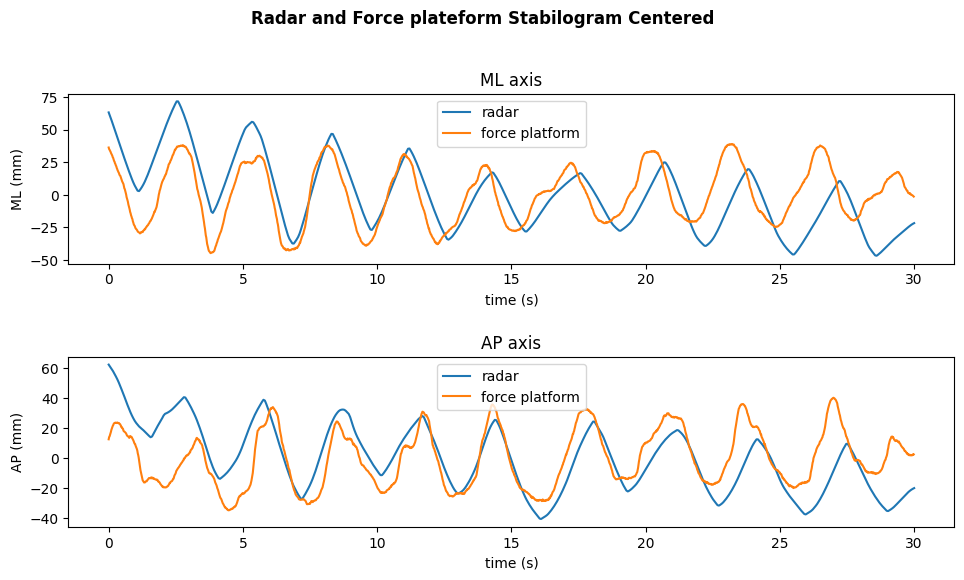

processing test file 13 !!!!
0.12851236027218937
0.11010956461867871


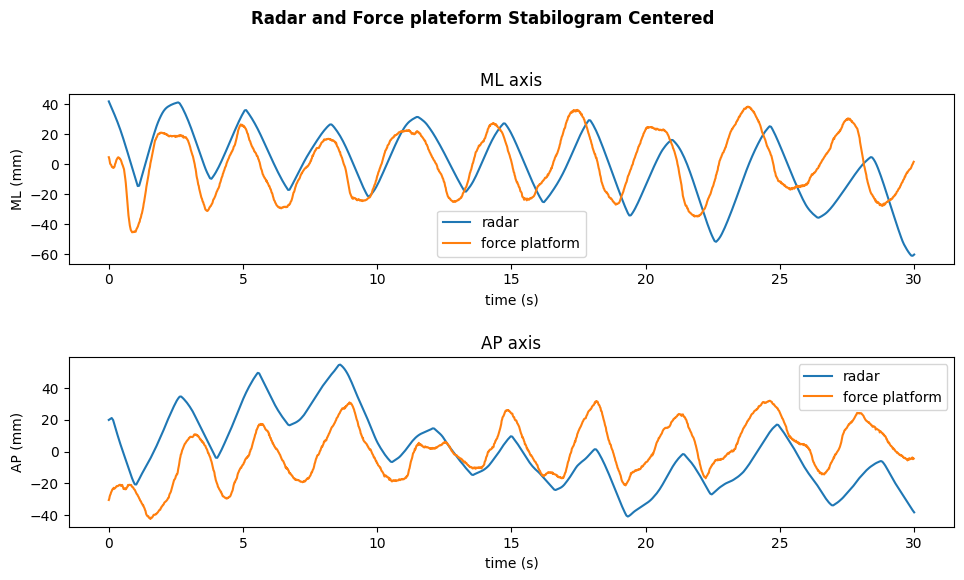

In [376]:
features_list = []

for i in range(1, 14):
    print(f"processing test file {i} !!!!")

    xml_file = f"../data/dataset2/platform/test{i}.xml"
    gait_file = f"../data/dataset2/platform/test{i}_gait.csv"
    radar_stabilo_file = f"../results/tables/dataset2/position/test{i}_radarposition.csv"

    begin_time = get_begin_time(xml_file)
    times, x_pos, y_pos = get_gait_samples(gait_file)

    times = times + begin_time
    positive_time = np.where(times >= 0)
    times = times[positive_time]
    x_pos = x_pos[positive_time]
    y_pos = y_pos[positive_time]

    x_pos -= np.mean(x_pos)
    y_pos -= np.mean(y_pos)

    plot_stabilo_comparison(radar_stabilo_file, times, x_pos, y_pos, f"../results/figures/dataset2/test{i}_stabilo.png")

    features = get_descriptors(x_pos, y_pos, times)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/tables/dataset2/platform_descriptors.csv")